In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Load Data

In [98]:
df = pd.read_csv('wine.csv')

In [99]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [100]:
df.isnull()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,False,False,False,False,False,False,False,False,False,False,False,False
1595,False,False,False,False,False,False,False,False,False,False,False,False
1596,False,False,False,False,False,False,False,False,False,False,False,False
1597,False,False,False,False,False,False,False,False,False,False,False,False


In [101]:
df.quality.unique()

array([5, 6, 7, 4, 8, 3])

### Values

In [102]:
X = df.drop(columns=['quality']).values
y = df['quality'].values
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_std[X_std == 0] = 1.0 # Prevent division by zero
X_scaled = (X - X_mean) / X_std
y_std = np.std(y)

### Split

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Linear Regression

In [104]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iterations=4000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = np.mean(y) 

        for i in range(self.n_iterations):
            y_hat = np.dot(X, self.weights) + self.bias
            
            error = y_hat - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            loss = np.mean(error**2)
            self.loss_history.append(loss)
            
            if np.isnan(loss):
                print(f"Divergence at iteration {i}. Lower the learning rate.")
                break

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

### Train

In [105]:
model = LinearRegressionGD()
model.fit(X_train, y_train)

### Predict

In [106]:
# Training performance
y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test performance
y_test_pred = model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

### Evaluation

In [107]:
print("Train MSE:", train_mse)
print("Test  MSE:", test_mse)
print("Train R2 :", train_r2)
print("Test  R2 :", test_r2)

Train MSE: 0.42535345938792235
Test  MSE: 0.39063126651472735
Train R2 : 0.3462060909973651
Test  R2 : 0.4022528476051932


### Plots

Text(0, 0.5, 'MSE')

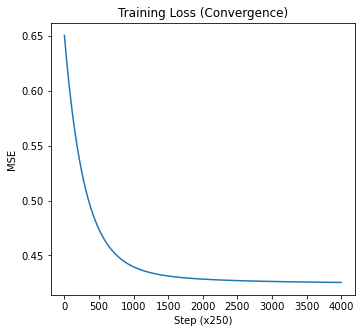

In [108]:
plt.figure(figsize=(12, 5))

# Plot training progress
plt.subplot(1, 2, 1)
plt.plot(model.loss_history)
plt.title("Training Loss (Convergence)")
plt.xlabel("Step (x250)")
plt.ylabel("MSE")

In [109]:
def regression_accuracy(y_true, y_pred, tolerance):
    correct = np.abs(y_true - y_pred) <= tolerance
    return np.mean(correct)

In [110]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

In [111]:
train_acc = regression_accuracy(y_train, y_train_pred, tolerance=2*y_std)
test_acc  = regression_accuracy(y_test, y_test_pred, tolerance=2*y_std)

print("Train Accuracy:", train_acc)
print("Test  Accuracy:", test_acc)
tolerances = [0.5, 1.0, 1.5, 2.0]
accuracies = []

y_test_pred = model.predict(X_test)

for t in tolerances:
    acc = regression_accuracy(y_test, y_test_pred, tolerance=t)
    accuracies.append(acc)

Train Accuracy: 0.9726348709929633
Test  Accuracy: 0.990625


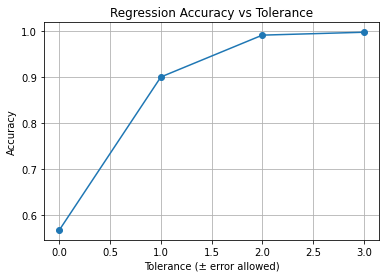

In [112]:
plt.figure()
plt.plot(accuracies, marker='o')
plt.xlabel("Tolerance (± error allowed)")
plt.ylabel("Accuracy")
plt.title("Regression Accuracy vs Tolerance")
plt.grid(True)
plt.show()